In [ ]:
!pip install -q \
    transformers \
    accelerate \
    bitsandbytes \
    sentencepiece \
    huggingface_hub \
    rouge-score \
    bert-score \
    pandas \
    numpy \
    matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.7 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import login

# Interactive authentication.
# Do NOT hard-code your Hugging Face token in the notebook.
login()

In [ ]:
import os, gc, json, random, re
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from rouge_score import rouge_scorer
from bert_score import score as bert_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

OUTPUT_DIR = Path("output")
FIGURE_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
BASE = "https://raw.githubusercontent.com/Law-AI/MILDSum/main/Data/MILDSum_Samples"

def fetch_sample_list():
    api_url = "https://api.github.com/repos/Law-AI/MILDSum/contents/Data/MILDSum_Samples"
    r = requests.get(api_url)
    if r.status_code == 200:
        return [item["name"] for item in r.json() if item["type"] == "dir"]
    return [f"Sample{i}" for i in range(1, 11)]

def download_case(case_name):
    case_dir = os.path.join("mildsum_samples", case_name)
    os.makedirs(case_dir, exist_ok=True)
    files = {}
    for fname in ["EN_Judgment.txt", "EN_Summary.txt", "HI_Summary.txt"]:
        url = f"{BASE}/{case_name}/{fname}"
        resp = requests.get(url)
        if resp.status_code == 200:
            text = resp.text
            with open(os.path.join(case_dir, fname), "w", encoding="utf-8") as f:
                f.write(text)
            files[fname] = text
        else:
            files[fname] = None
    return files

cases = fetch_sample_list()
print("Cases found:", cases, len(cases))

data = []
for c in cases:
    d = download_case(c)
    if d["EN_Judgment.txt"] and d["HI_Summary.txt"]:
        data.append({
            "case_id": c,
            "judgment": d["EN_Judgment.txt"],
            "en_summary": d["EN_Summary.txt"],
            "hi_reference": d["HI_Summary.txt"],
        })

df = pd.DataFrame(data)
df.to_csv(OUTPUT_DIR / "mildsum_10cases.csv", index=False)

assert len(df) == 10, f"Expected 10 MILDSum samples, found {len(df)}"
required_cols = ["case_id", "judgment", "en_summary", "hi_reference"]
assert all(col in df.columns for col in required_cols)
assert df["judgment"].notna().all()
assert df["hi_reference"].notna().all()
assert df["en_summary"].notna().all()

dataset_audit = pd.DataFrame({
    "case_id": df["case_id"],
    "judgment_chars": df["judgment"].str.len(),
    "reference_hi_chars": df["hi_reference"].str.len()
})
display(dataset_audit)
print(f"Verified {len(df)} complete MILDSum samples.")

Cases found: ['Sample_1', 'Sample_10', 'Sample_2', 'Sample_3', 'Sample_4', 'Sample_5', 'Sample_6', 'Sample_7', 'Sample_8', 'Sample_9'] 10


,case_id,judgment_chars,reference_hi_chars
0,Sample_1,9560,4357
1,Sample_10,13513,5087
2,Sample_2,26678,3488
3,Sample_3,36201,3684
4,Sample_4,6117,2880
5,Sample_5,17994,5064
6,Sample_6,35701,3798
7,Sample_7,12196,2632
8,Sample_8,13611,1822
9,Sample_9,15278,3124


Verified 10 complete MILDSum samples.


## Model Selection

The experiment uses Qwen3.5-4B-Instruct, an open-access instruction-tuned
multilingual model requiring no license gating. Both Llama-3.2-3B-Instruct
and Gemma-3-4B-it require manual license approval on Hugging Face, which
was not feasible within the project timeline. Qwen3.5-4B-Instruct supports
Hindi generation and runs efficiently under 4-bit quantization on the
available GPU. The controlled variable in this experiment is the prompting
strategy (Zero-shot, Few-shot, Structured CoT), not the model itself.

In [ ]:
MODEL_ID = "Qwen/Qwen3.5-4B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)
model.eval()
print("Model loaded:", MODEL_ID)

config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

...

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Model loaded: Qwen/Qwen3.5-4B


In [ ]:
print(f"Approximate model memory footprint: {model.get_memory_footprint()/1e9:.2f} GB")

Approximate model memory footprint: 3.06 GB


In [ ]:
def count_tokens(text):
    return len(tok(text, add_special_tokens=False)["input_ids"])

df["judgment_tokens"] = df["judgment"].apply(count_tokens)
df["reference_tokens"] = df["hi_reference"].apply(count_tokens)

display(df[["case_id", "judgment_tokens", "reference_tokens"]])
print(df["judgment_tokens"].describe())

,case_id,judgment_tokens,reference_tokens
0,Sample_1,2415,2815
1,Sample_10,3438,3300
2,Sample_2,6279,2299
3,Sample_3,8533,2377
4,Sample_4,1398,1873
5,Sample_5,4596,3312
6,Sample_6,9009,2393
7,Sample_7,2978,1697
8,Sample_8,3457,1174
9,Sample_9,3764,1995


count      10.000000
mean     4586.700000
std      2554.702855
min      1398.000000
25%      3093.000000
50%      3610.500000
75%      5858.250000
max      9009.000000
Name: judgment_tokens, dtype: float64


In [ ]:
def generate(prompt, max_new_tokens=800):
    messages = [{"role": "user", "content": prompt}]

    text = tok.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,   # must be set here, in the string-template step
    )

    inputs = tok(text, return_tensors="pt", truncation=True, max_length=3000).to(model.device)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.1,
            pad_token_id=tok.eos_token_id,
        )

    generated_text = tok.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
    generated_text = re.sub(r"<think>.*?</think>", "", generated_text, flags=re.DOTALL)
    generated_text = re.sub(r"^\s*(assistant)?\s*<think>.*", "", generated_text, flags=re.DOTALL)

    del inputs, out
    torch.cuda.empty_cache()
    return generated_text.strip()

In [ ]:
def truncate_by_tokens(text, max_tokens=1500):
    ids = tok(text, truncation=True, max_length=max_tokens)["input_ids"]
    return tok.decode(ids, skip_special_tokens=True)

def zero_shot_prompt(judgment):
    return f"""
You are performing English-to-Hindi legal summarization.

Read the English court judgment below and produce a concise Hindi legal summary.

The summary must:
- preserve the important facts;
- identify the main legal issue;
- preserve the court's key reasoning;
- clearly state the final decision;
- use clear and appropriate Hindi legal terminology;
- not introduce any fact, law, argument, or decision not supported by the judgment.

Return only the final Hindi summary.

ENGLISH JUDGMENT:
{truncate_by_tokens(judgment, 1500)}

HINDI SUMMARY:
""".strip()

def few_shot_prompt(judgment, examples):
    blocks = []
    for i, (ex_j, ex_h, ex_id) in enumerate(examples, 1):
        blocks.append(f"""EXAMPLE {i} (Case: {ex_id})
ENGLISH JUDGMENT:
{truncate_by_tokens(ex_j, 600)}

HINDI SUMMARY:
{ex_h}""")
    demo_block = "\n\n".join(blocks)
    return f"""
You are performing English-to-Hindi legal summarization.

Below are examples of English legal judgments and their Hindi summaries.

{demo_block}

Now summarize the new judgment. The summary must:
- preserve the important facts;
- identify the main legal issue;
- preserve the court's key reasoning;
- clearly state the final decision;
- use clear and appropriate Hindi legal terminology;
- not introduce information unsupported by the judgment.

Return only the final Hindi summary.

NEW ENGLISH JUDGMENT:
{truncate_by_tokens(judgment, 1500)}

HINDI SUMMARY:
""".strip()

def cot_prompt(judgment):
    return f"""
You are performing English-to-Hindi legal summarization.

First identify the following information from the English judgment, then
produce a concise Hindi legal summary based only on that information.
Do not add information not supported by the judgment.

Use exactly this output format:

FACTS:
...

LEGAL ISSUE:
...

COURT REASONING:
...

FINAL DECISION:
...

FINAL HINDI SUMMARY:
...

ENGLISH JUDGMENT:
{truncate_by_tokens(judgment, 1500)}
""".strip()

def extract_final_summary(cot_output):
    m = re.search(r"final hindi summary\s*[:\-]?", cot_output, flags=re.IGNORECASE)
    if m:
        return cot_output[m.end():].strip()
    return cot_output.strip()

In [ ]:
def generate_few_shot_chat(judgment, examples, max_new_tokens=800):

    messages = []

    # Few-shot demonstrations
    for ex_j, ex_h, ex_id in examples:
        ex_j_short = truncate_by_tokens(ex_j, 450)
        ex_h_short = truncate_by_tokens(ex_h, 300)

        messages.append({
            "role": "user",
            "content": (
                "Summarize the following English court judgment in Hindi.\n\n"
                + ex_j_short
            )
        })

        messages.append({
            "role": "assistant",
            "content": ex_h_short
        })

    # Target judgment
    target = truncate_by_tokens(judgment, 1500)

    messages.append({
        "role": "user",
        "content": (
            "Summarize the following English court judgment in Hindi.\n\n"
            "STRICT OUTPUT RULES:\n"
            "1. Output ONLY the final Hindi summary.\n"
            "2. Do NOT show analysis or reasoning.\n"
            "3. Do NOT show a thinking process.\n"
            "4. Do NOT write <think> tags.\n"
            "5. Do NOT mention the demonstrations.\n"
            "6. Do NOT invent names, dates, amounts, facts, or legal conclusions.\n"
            "7. Preserve the meaning of the judgment.\n"
            "8. Include important facts, legal issue, court reasoning, and final decision "
            "only when supported by the judgment.\n\n"
            "SOURCE JUDGMENT:\n"
            + target
            + "\n\n"
            "FINAL HINDI SUMMARY:"
        )
    })

    text = tok.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    inputs = tok(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=3000
    ).to(model.device)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.1,
            pad_token_id=tok.eos_token_id
        )

    generated_tokens = out[0][inputs["input_ids"].shape[-1]:]

    output = tok.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    # Remove explicit thinking blocks if generated
    output = re.sub(
        r"<think>.*?(</think>|$)",
        "",
        output,
        flags=re.DOTALL | re.IGNORECASE
    )

    # Remove common reasoning prefixes if they appear
    reasoning_markers = [
        "Thinking Process:",
        "Thinking process:",
        "Analysis:",
        "analysis:",
        "Let's analyze",
        "Let’s analyze",
        "I need to",
        "We need to",
    ]

    for marker in reasoning_markers:
        if marker in output:
            output = output.split(marker)[0].strip()

    # Remove accidental assistant prefix
    output = re.sub(
        r"^\s*assistant\s*:?\s*",
        "",
        output,
        flags=re.IGNORECASE
    )

    del inputs, out
    torch.cuda.empty_cache()
    gc.collect()

    return output.strip()

In [ ]:
test_output = generate_few_shot_chat(
    df.loc[0, "judgment"],
    test_examples
)

print("=" * 80)
print("FEW-SHOT TEST — Sample_1")
print("=" * 80)
print(test_output)

FEW-SHOT TEST — Sample_1
go to the emergency room
assistant


पेटिशनिस्ट ने दिल्ली उच्च न्यायालय के अधिकारी होने के बावजूद, कोविड-19 से जुड़ी चिकित्सा उपचार के दौरान उत्पन्न खर्चों का पूर्ण रूप से वापस नहीं मिलने के कारण इस विवाद में शिकायत दर्ज की है। पेटिशनिस्ट ने कहा कि वह 22.04.2021 से 07.06.2021 तक उत्तर प्रदेश सरकार द्वारा नियंत्रित होशपिटल में उपचार के लिए प्रवेश किया था, जिसमें उसे ऑक्सीजन की कमी के कारण वाइलेटर पर तीन हफ्ते तक रखना पड़ा था। उसने 24 लाख 2 हजार 380 रुपये का पूरा राशि चुकाई थी, लेकिन उत्तर प्रदेश सरकार ने केवल 7 लाख 8 हजार 500 रुपये का वापस दिया है। उत्तर प्रदेश सरकार ने बाकी राशि वापस न करने का दावा किया है क्योंकि होशपिटल ने 20.06.2020 की सर्कुलर के अनुसार निर्धारित दरों से ऊपर फीस लगाई है। पेटिशनिस्ट ने कहा कि यदि होशपिटल ने सर्कुलर का उल्लंघन किया है, तो उत्तर प्रदेश सरकार को उससे कार्रवाई करनी चाहिए और पेटिशनिस्ट को पूरी राशि वापस देनी चाहिए। दूसरी ओर, उत्तर प्रदेश सरकार ने कहा कि होशपिटल को यह स्पष्ट करना होगा कि वह क्यों सर्कुलर का उल्लंघन करता है और उसे अ

In [ ]:
length_rows = []
for idx, row in df.iterrows():
    fs_examples = get_few_shot_examples(idx, df, N_SHOTS)
    prompts = {
        "zero_shot": zero_shot_prompt(row["judgment"]),
        "few_shot": few_shot_prompt(row["judgment"], fs_examples),
        "cot": cot_prompt(row["judgment"]),
    }
    for method, prompt in prompts.items():
        length_rows.append({"case_id": row["case_id"], "method": method, "prompt_tokens": count_tokens(prompt)})

prompt_length_df = pd.DataFrame(length_rows)
display(prompt_length_df.pivot(index="case_id", columns="method", values="prompt_tokens"))

method,cot,few_shot,zero_shot
case_id,,,
Sample_1,1601,7860,1615
Sample_10,1601,8568,1615
Sample_2,1601,8557,1615
Sample_3,1601,6430,1615
Sample_4,1498,8067,1512
Sample_5,1601,7374,1615
Sample_6,1601,8541,1615
Sample_7,1601,8055,1615
Sample_8,1601,6952,1615


In [ ]:
results = []

for idx, row in df.iterrows():

    case_id = row["case_id"]
    print(f"Processing {case_id} ...")

    # Few-shot examples
    fs_examples = get_few_shot_examples(idx, df, N_SHOTS)

    # Zero-shot
    zs = generate(
        zero_shot_prompt(row["judgment"])
    )

    torch.cuda.empty_cache()
    gc.collect()

    # Few-shot
    fs = generate_few_shot_chat(
        row["judgment"],
        fs_examples
    )

    torch.cuda.empty_cache()
    gc.collect()

    # Structured CoT
    cot_raw = generate(
        cot_prompt(row["judgment"]),
        max_new_tokens=600
    )

    torch.cuda.empty_cache()
    gc.collect()

    cot_summary = extract_final_summary(cot_raw)

    # Store results
    results.append({
        "case_id": case_id,
        "model_id": MODEL_ID,
        "reference_hi": row["hi_reference"],
        "zero_shot": zs,
        "few_shot": fs,
        "cot_raw": cot_raw,
        "cot_summary": cot_summary,
        "few_shot_demo_cases": ", ".join(
            e[2] for e in fs_examples
        ),
        "seed": SEED,
        "do_sample": False
    })

    # Save checkpoint
    pd.DataFrame(results).to_csv(
        OUTPUT_DIR / "generated_summaries_checkpoint.csv",
        index=False
    )

    print(f"✓ Completed {case_id}")


# Final results
results_df = pd.DataFrame(results)

results_df.to_csv(
    OUTPUT_DIR / "generated_summaries.csv",
    index=False
)

print("\nNumber of samples:", len(results_df))

display(
    results_df[
        [
            "case_id",
            "few_shot_demo_cases",
            "zero_shot",
            "few_shot",
            "cot_summary"
        ]
    ]
)

Processing Sample_1 ...
✓ Completed Sample_1
Processing Sample_10 ...
✓ Completed Sample_10
Processing Sample_2 ...
✓ Completed Sample_2
Processing Sample_3 ...
✓ Completed Sample_3
Processing Sample_4 ...
✓ Completed Sample_4
Processing Sample_5 ...
✓ Completed Sample_5
Processing Sample_6 ...
✓ Completed Sample_6
Processing Sample_7 ...
✓ Completed Sample_7
Processing Sample_8 ...
✓ Completed Sample_8
Processing Sample_9 ...
✓ Completed Sample_9

Number of samples: 10


,case_id,few_shot_demo_cases,zero_shot,few_shot,cot_summary
0,Sample_1,"Sample_10, Sample_7",**संक्षिप्त हिंदी कानूनी सारांश:**\n\n1. **मुख...,go to the emergency room\nassistant\n\n\nपेटिश...,FACTS:\nपेटिशनर दिल्ली उच्च न्यायालय सेवा का ए...
1,Sample_10,"Sample_6, Sample_5",यह मामला सी.पी.सी.ए. के धारा ४३८ के तहत पूर्व-...,) of the Non-Domesticated\nassistant\n\n\nअदाल...,"FACTS:\nपेटिशनर ने एनडीपीएस अधिनियम, १९८ॵ के ध..."
2,Sample_2,"Sample_6, Sample_10",**हिंदी कानूनी सारांश:**\n\nयह विवरण एक कंपनी ...,"Engineer, EM&\nassistant\n\n\nपंजाब एंड हरियान...",FACTS:\nपेटिशनर कंपनी है जो जम्मू में बारी ब्र...
3,Sample_3,"Sample_8, Sample_6",यह विधवा (पत्नी) के प्रति अपीलकर्ता (पति) द्वा...,", Amravati for dissolution of marriage on grou...",पति ने पत्नी के खिलाफ कड़ी व्यवहार और त्याग के...
4,Sample_4,"Sample_9, Sample_5","यह मामला कांटेक्ट क्रिमिनल नंबर २४२, वर्ष २०२२...",.\nassistant\n\n\nअदालत ने सीआर नं. २४२/२०२२ म...,"FACTS:\nमहाराष्ट्र के थाना काशीमिरा (मिरा रोड,..."
5,Sample_5,"Sample_1, Sample_7",यह मामला तमामि (तमाली) और राजनीगंधा के ट्रेडमा...,I.A. 15936/2022 (under Order XIII-A CPC).\nass...,यह मामला एक ट्रेडमार्क और कॉपीराइट उल्लंघन के ...
6,Sample_6,"Sample_3, Sample_10",**संक्षिप्त हिंदी कानूनी सारांश:**\n\n**प्रमुख...,complaints about the appellant’s conduct towar...,पक्षीयों ने 11 नवंबर 2012 को सिख रीत-रिवाजों स...
7,Sample_7,"Sample_1, Sample_3",यह मामला क्रमिक प्रक्रिया कोड (CrPC) की धारा 4...,similarly. Anticipatory bail is granted based ...,FACTS:\nपेटिशनर ने क्राइमल प्रोसेस कोड की धारा...
8,Sample_8,"Sample_6, Sample_7",यह मामला एनडीपीएस अधिनियम के धारा 20 और 29 तहत...,of 250 gm each from each bag separately and ke...,FACTS:\nमहामूरी के आधार पर दो व्यक्तियों (अजित...
9,Sample_9,"Sample_3, Sample_8",यह संक्षिप्त हिंदी कानूनी सारांश है:\n\n**संपू...,order dated 04. best\nassistant\n\nइस मामले मे...,FACTS:\nपक्षी (महिला) ने पंजीकरण विभाग नं. 8/2...


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
def clean_few_shot_output(text):

    if pd.isna(text):
        return ""

    text = str(text).strip()

    # Remove everything before the final "assistant" marker
    if "assistant" in text.lower():
        parts = re.split(r"assistant", text, maxsplit=1, flags=re.IGNORECASE)
        text = parts[1].strip()

    # Remove accidental thinking blocks if present
    text = re.sub(
        r"<think>.*?</think>",
        "",
        text,
        flags=re.DOTALL | re.IGNORECASE
    )

    return text.strip()


results_df["few_shot_clean"] = results_df["few_shot"].apply(
    clean_few_shot_output
)

display(
    results_df[
        ["case_id", "few_shot", "few_shot_clean"]
    ]
)

,case_id,few_shot,few_shot_clean
0,Sample_1,go to the emergency room\nassistant\n\n\nपेटिश...,पेटिशनिस्ट ने दिल्ली उच्च न्यायालय के अधिकारी ...
1,Sample_10,) of the Non-Domesticated\nassistant\n\n\nअदाल...,अदालत ने सी.पी.सी.आइ. (CrPC) की धारा ४३८ के तह...
2,Sample_2,"Engineer, EM&\nassistant\n\n\nपंजाब एंड हरियान...",पंजाब एंड हरियाना हाईकोर्ट ने एक कंपनी के विरो...
3,Sample_3,", Amravati for dissolution of marriage on grou...",इस मामले में पति ने अपनी पत्नी के खिलाफ क्रूरत...
4,Sample_4,.\nassistant\n\n\nअदालत ने सीआर नं. २४२/२०२२ म...,अदालत ने सीआर नं. २४२/२०२२ में अभियोग के तहत इ...
5,Sample_5,I.A. 15936/2022 (under Order XIII-A CPC).\nass...,
6,Sample_6,complaints about the appellant’s conduct towar...,इस अपील में पति ने अपने विवाह विच्छेदन के लिए ...
7,Sample_7,similarly. Anticipatory bail is granted based ...,"इस मामले में, पीटनेर ने सी.पी.सी. की धारा 438 ..."
8,Sample_8,of 250 gm each from each bag separately and ke...,"इस मामले में, पीटनेर ने दावा किया कि नार्कोटिक..."
9,Sample_9,order dated 04. best\nassistant\n\nइस मामले मे...,"इस मामले में, अभियुता ने परिवार कोर्ट के निर्द..."


In [ ]:
print(results_df.loc[
    results_df["case_id"] == "Sample_5",
    "few_shot"
].iloc[0])

I.A. 15936/2022 (under Order XIII-A CPC).
assistant


In [ ]:
print("RAW LENGTH:",
      len(results_df.loc[
          results_df["case_id"] == "Sample_5",
          "few_shot"
      ].iloc[0]))

print("CLEAN LENGTH:",
      len(results_df.loc[
          results_df["case_id"] == "Sample_5",
          "few_shot_clean"
      ].iloc[0]))

RAW LENGTH: 51
CLEAN LENGTH: 0


In [ ]:
print(
    results_df[
        ["case_id", "few_shot_clean"]
    ].assign(
        few_shot_status=lambda x: x["few_shot_clean"].apply(
            lambda s: "FAILED — NO SUMMARY"
            if not str(s).strip()
            else "OK"
        )
    )
)

     case_id                                     few_shot_clean  \
0   Sample_1  पेटिशनिस्ट ने दिल्ली उच्च न्यायालय के अधिकारी ...   
1  Sample_10  अदालत ने सी.पी.सी.आइ. (CrPC) की धारा ४३८ के तह...   
2   Sample_2  पंजाब एंड हरियाना हाईकोर्ट ने एक कंपनी के विरो...   
3   Sample_3  इस मामले में पति ने अपनी पत्नी के खिलाफ क्रूरत...   
4   Sample_4  अदालत ने सीआर नं. २४२/२०२२ में अभियोग के तहत इ...   
5   Sample_5                                                      
6   Sample_6  इस अपील में पति ने अपने विवाह विच्छेदन के लिए ...   
7   Sample_7  इस मामले में, पीटनेर ने सी.पी.सी. की धारा 438 ...   
8   Sample_8  इस मामले में, पीटनेर ने दावा किया कि नार्कोटिक...   
9   Sample_9  इस मामले में, अभियुता ने परिवार कोर्ट के निर्द...   

       few_shot_status  
0                   OK  
1                   OK  
2                   OK  
3                   OK  
4                   OK  
5  FAILED — NO SUMMARY  
6                   OK  
7                   OK  
8                   OK  
9           

In [ ]:
rouge = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=False
)

rouge_rows = []

for _, row in results_df.iterrows():

    reference = normalize_text(row["reference_hi"])

    methods = {
        "Zero-shot": normalize_text(row["zero_shot"]),

        # Use cleaned Few-shot output
        "Few-shot": normalize_text(row["few_shot_clean"]),

        "Structured CoT": normalize_text(row["cot_summary"])
    }

    for method, prediction in methods.items():

        scores = rouge.score(
            reference,
            prediction
        )

        rouge_rows.append({
            "case_id": row["case_id"],
            "method": method,
            "rouge1": scores["rouge1"].fmeasure,
            "rouge2": scores["rouge2"].fmeasure,
            "rougeL": scores["rougeL"].fmeasure
        })

rouge_results = pd.DataFrame(rouge_rows)

print("ROUGE rows:", len(rouge_results))
display(rouge_results.head(10))

ROUGE rows: 30


,case_id,method,rouge1,rouge2,rougeL
0,Sample_1,Zero-shot,0.218750,0.064516,0.156250
1,Sample_1,Few-shot,0.342857,0.117647,0.285714
2,Sample_1,Structured CoT,0.525000,0.333333,0.400000
3,Sample_10,Zero-shot,0.000000,0.000000,0.000000
4,Sample_10,Few-shot,0.000000,0.000000,0.000000
5,Sample_10,Structured CoT,0.000000,0.000000,0.000000
6,Sample_2,Zero-shot,0.000000,0.000000,0.000000
7,Sample_2,Few-shot,0.370370,0.080000,0.370370
8,Sample_2,Structured CoT,0.000000,0.000000,0.000000
9,Sample_3,Zero-shot,0.000000,0.000000,0.000000


In [ ]:
print(rouge_results.groupby("method")[["rouge1", "rouge2", "rougeL"]].mean())

                  rouge1    rouge2    rougeL
method                                      
Few-shot        0.189434  0.068098  0.160643
Structured CoT  0.155238  0.050000  0.111771
Zero-shot       0.093382  0.028915  0.065708


In [ ]:
bert_rows = []

for _, row in results_df.iterrows():

    reference = normalize_text(row["reference_hi"])

    methods = {
        "Zero-shot": normalize_text(row["zero_shot"]),
        "Few-shot": normalize_text(row["few_shot_clean"]),
        "Structured CoT": normalize_text(row["cot_summary"])
    }

    for method, prediction in methods.items():

        if not prediction.strip():

            P = R = F1 = 0.0

        else:

            P, R, F1 = bert_score(
                [prediction],
                [reference],
                lang="hi",
                model_type="bert-base-multilingual-cased",
                verbose=False
            )

            P = float(P[0])
            R = float(R[0])
            F1 = float(F1[0])

        bert_rows.append({
            "case_id": row["case_id"],
            "method": method,
            "bert_precision": P,
            "bert_recall": R,
            "bertscore_f1": F1
        })

bert_results = pd.DataFrame(bert_rows)

print("BERTScore rows:", len(bert_results))
display(bert_results.head(10))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTScore rows: 30


,case_id,method,bert_precision,bert_recall,bertscore_f1
0,Sample_1,Zero-shot,0.732251,0.753295,0.742624
1,Sample_1,Few-shot,0.744290,0.738106,0.741185
2,Sample_1,Structured CoT,0.734510,0.743946,0.739198
3,Sample_10,Zero-shot,0.680964,0.699292,0.690007
4,Sample_10,Few-shot,0.681925,0.703687,0.692635
5,Sample_10,Structured CoT,0.681987,0.696584,0.689209
6,Sample_2,Zero-shot,0.723762,0.730600,0.727165
7,Sample_2,Few-shot,0.788951,0.757425,0.772866
8,Sample_2,Structured CoT,0.738694,0.739828,0.739260
9,Sample_3,Zero-shot,0.763427,0.754050,0.758710


In [ ]:
eval_df = pd.merge(
    rouge_results,
    bert_results,
    on=["case_id", "method"],
    how="inner"
)

print("Evaluation rows:", len(eval_df))

assert len(eval_df) == 30

display(eval_df.head(10))

Evaluation rows: 30


,case_id,method,rouge1,rouge2,rougeL,bert_precision,bert_recall,bertscore_f1
0,Sample_1,Zero-shot,0.218750,0.064516,0.156250,0.732251,0.753295,0.742624
1,Sample_1,Few-shot,0.342857,0.117647,0.285714,0.744290,0.738106,0.741185
2,Sample_1,Structured CoT,0.525000,0.333333,0.400000,0.734510,0.743946,0.739198
3,Sample_10,Zero-shot,0.000000,0.000000,0.000000,0.680964,0.699292,0.690007
4,Sample_10,Few-shot,0.000000,0.000000,0.000000,0.681925,0.703687,0.692635
5,Sample_10,Structured CoT,0.000000,0.000000,0.000000,0.681987,0.696584,0.689209
6,Sample_2,Zero-shot,0.000000,0.000000,0.000000,0.723762,0.730600,0.727165
7,Sample_2,Few-shot,0.370370,0.080000,0.370370,0.788951,0.757425,0.772866
8,Sample_2,Structured CoT,0.000000,0.000000,0.000000,0.738694,0.739828,0.739260
9,Sample_3,Zero-shot,0.000000,0.000000,0.000000,0.763427,0.754050,0.758710


In [ ]:
metric_cols = ["rouge1", "rouge2", "rougeL", "bertscore_f1"]

summary_mean = eval_df.groupby("method")[metric_cols].mean()
summary_std = eval_df.groupby("method")[metric_cols].std()

summary_mean.round(4).to_csv(OUTPUT_DIR / "automatic_eval_summary_mean.csv")
summary_std.round(4).to_csv(OUTPUT_DIR / "automatic_eval_summary_std.csv")

formatted_summary = summary_mean.copy()
for col in metric_cols:
    formatted_summary[col] = [f"{m:.4f} ± {s:.4f}" for m, s in zip(summary_mean[col], summary_std[col])]
display(formatted_summary)

,rouge1,rouge2,rougeL,bertscore_f1
method,,,,
Few-shot,0.1894 ± 0.2254,0.0681 ± 0.1251,0.1606 ± 0.2007,0.6458 ± 0.2282
Structured CoT,0.1552 ± 0.2035,0.0500 ± 0.1125,0.1118 ± 0.1292,0.7042 ± 0.0308
Zero-shot,0.0934 ± 0.1423,0.0289 ± 0.0547,0.0657 ± 0.0936,0.7242 ± 0.0233


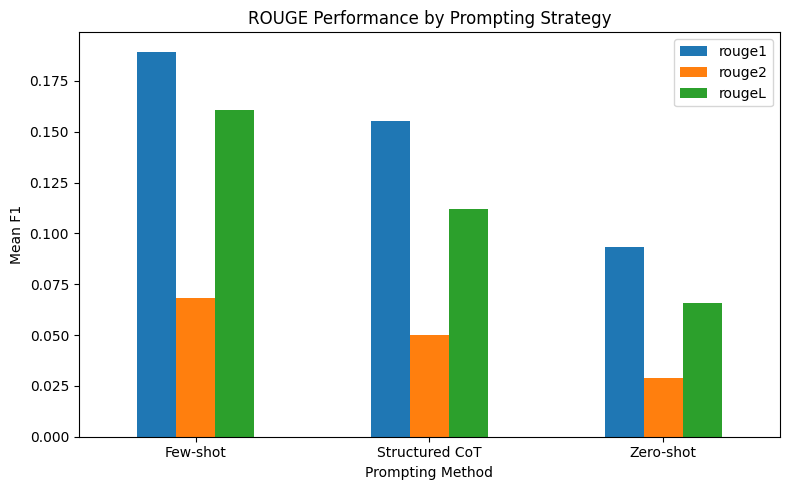

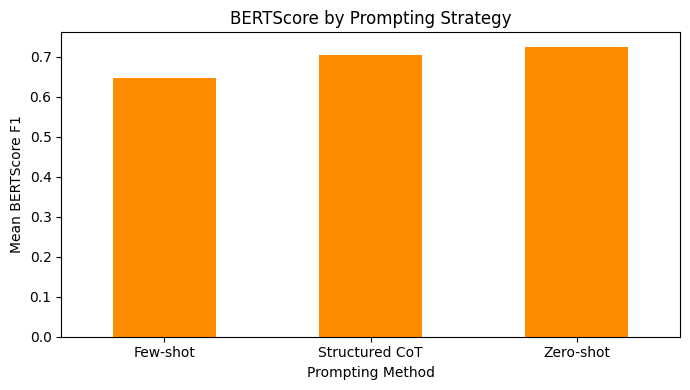

In [ ]:
plot_df = eval_df.groupby("method")[["rouge1", "rouge2", "rougeL"]].mean()
ax = plot_df.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Mean F1"); ax.set_xlabel("Prompting Method")
ax.set_title("ROUGE Performance by Prompting Strategy")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIGURE_DIR / "rouge_comparison.png", dpi=300)
plt.show()

bert_plot = eval_df.groupby("method")["bertscore_f1"].mean()
ax = bert_plot.plot(kind="bar", figsize=(7, 4), color="darkorange")
ax.set_ylabel("Mean BERTScore F1"); ax.set_xlabel("Prompting Method")
ax.set_title("BERTScore by Prompting Strategy")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIGURE_DIR / "bertscore_comparison.png", dpi=300)
plt.show()

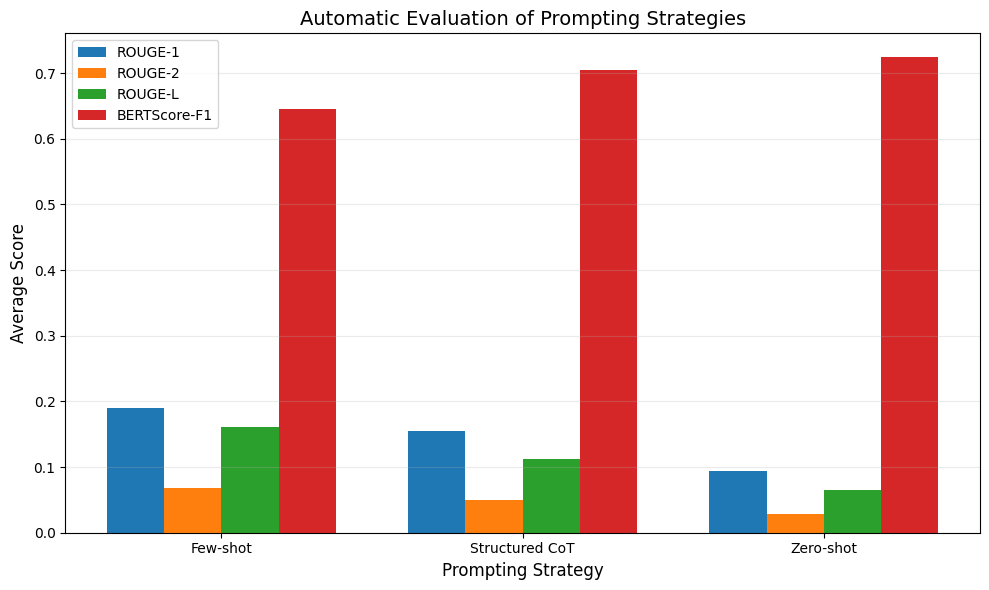

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Results from your automatic evaluation
data = {
    "Method": ["Few-shot", "Structured CoT", "Zero-shot"],
    "ROUGE-1": [0.1894, 0.1552, 0.0934],
    "ROUGE-2": [0.0681, 0.0500, 0.0289],
    "ROUGE-L": [0.1606, 0.1118, 0.0657],
    "BERTScore-F1": [0.6458, 0.7042, 0.7242]
}

df_plot = pd.DataFrame(data)

# -----------------------------
# GRAPH 1: Average metric scores
# -----------------------------
metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore-F1"]

x = np.arange(len(df_plot))
width = 0.19

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - 1.5) * width,
        df_plot[metric],
        width,
        label=metric
    )

ax.set_xlabel("Prompting Strategy", fontsize=12)
ax.set_ylabel("Average Score", fontsize=12)
ax.set_title("Automatic Evaluation of Prompting Strategies", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_plot["Method"])
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("graph_1_automatic_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

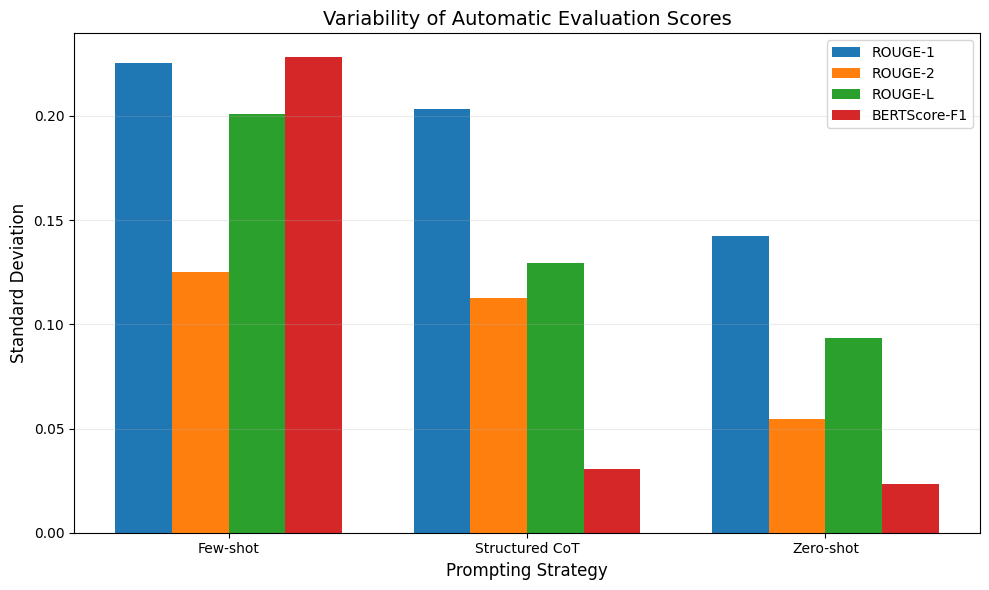

In [ ]:
# Standard deviations from your results
std_data = {
    "Method": ["Few-shot", "Structured CoT", "Zero-shot"],
    "ROUGE-1": [0.2254, 0.2035, 0.1423],
    "ROUGE-2": [0.1251, 0.1125, 0.0547],
    "ROUGE-L": [0.2007, 0.1292, 0.0936],
    "BERTScore-F1": [0.2282, 0.0308, 0.0233]
}

df_std = pd.DataFrame(std_data)

x = np.arange(len(df_std))
width = 0.19

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - 1.5) * width,
        df_std[metric],
        width,
        label=metric
    )

ax.set_xlabel("Prompting Strategy", fontsize=12)
ax.set_ylabel("Standard Deviation", fontsize=12)
ax.set_title("Variability of Automatic Evaluation Scores", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_std["Method"])
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("graph_2_metric_variability.png", dpi=300, bbox_inches="tight")
plt.show()

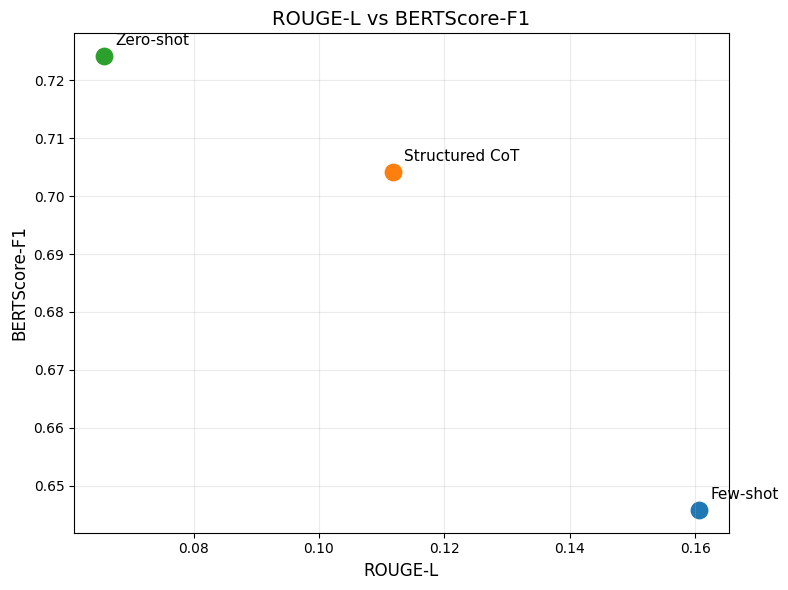

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in df_plot.iterrows():
    ax.scatter(
        row["ROUGE-L"],
        row["BERTScore-F1"],
        s=140
    )
    ax.annotate(
        row["Method"],
        (row["ROUGE-L"], row["BERTScore-F1"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11
    )

ax.set_xlabel("ROUGE-L", fontsize=12)
ax.set_ylabel("BERTScore-F1", fontsize=12)
ax.set_title("ROUGE-L vs BERTScore-F1", fontsize=14)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("graph_3_metric_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================
# SAVE ALL EXPERIMENT RESULTS TO GOOGLE DRIVE
# ============================================

from google.colab import drive
from pathlib import Path
import shutil
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Create project folder
DRIVE_DIR = Path(
    "/content/drive/MyDrive/Cross_Lingual_Legal_Summarization"
)

DRIVE_DIR.mkdir(parents=True, exist_ok=True)

# Create subfolders
folders = [
    "generated_summaries",
    "automatic_metrics",
    "graphs",
    "manual_evaluation",
    "error_analysis",
    "presentation"
]

for folder in folders:
    (DRIVE_DIR / folder).mkdir(parents=True, exist_ok=True)

print("Drive folder created:")
print(DRIVE_DIR)

Mounted at /content/drive
Drive folder created:
/content/drive/MyDrive/Cross_Lingual_Legal_Summarization


In [ ]:
# ============================================
# SAVE GENERATED SUMMARIES + METRICS
# ============================================

# Generated summaries
if "results_df" in globals():
    results_df.to_csv(
        DRIVE_DIR / "generated_summaries" / "generated_summaries.csv",
        index=False
    )
    print("✓ generated_summaries.csv saved")

# ROUGE results
if "rouge_results" in globals():
    rouge_results.to_csv(
        DRIVE_DIR / "automatic_metrics" / "rouge_results.csv",
        index=False
    )
    print("✓ rouge_results.csv saved")

# BERTScore results
if "bert_results" in globals():
    bert_results.to_csv(
        DRIVE_DIR / "automatic_metrics" / "bertscore_results.csv",
        index=False
    )
    print("✓ bertscore_results.csv saved")

# Combined evaluation
if "eval_df" in globals():
    eval_df.to_csv(
        DRIVE_DIR / "automatic_metrics" / "all_automatic_results.csv",
        index=False
    )
    print("✓ all_automatic_results.csv saved")

print("\nAll current result files saved to:")
print(DRIVE_DIR)

✓ generated_summaries.csv saved
✓ rouge_results.csv saved
✓ bertscore_results.csv saved
✓ all_automatic_results.csv saved

All current result files saved to:
/content/drive/MyDrive/Cross_Lingual_Legal_Summarization


In [ ]:
# ============================================
# SAVE GRAPH FILES TO GOOGLE DRIVE
# ============================================

import shutil
from pathlib import Path

graph_files = [
    "graph_1_automatic_comparison.png",
    "graph_2_metric_variability.png",
    "graph_3_metric_tradeoff.png"
]

for filename in graph_files:
    source = Path(filename)

    if source.exists():
        destination = DRIVE_DIR / "graphs" / filename
        shutil.copy2(source, destination)
        print(f"✓ Saved: {filename}")
    else:
        print(f"⚠ Not found: {filename}")

print("\nGraphs folder:")
print(DRIVE_DIR / "graphs")

✓ Saved: graph_1_automatic_comparison.png
✓ Saved: graph_2_metric_variability.png
✓ Saved: graph_3_metric_tradeoff.png

Graphs folder:
/content/drive/MyDrive/Cross_Lingual_Legal_Summarization/graphs


In [ ]:
# ============================================
# SAVE CURRENT RESULTS TO GOOGLE DRIVE
# ============================================

from google.colab import drive
from pathlib import Path

# Mount Drive
drive.mount('/content/drive')

# Main folder
DRIVE_DIR = Path(
    "/content/drive/MyDrive/Cross_Lingual_Legal_Summarization"
)

# Create folders
for folder in [
    "generated_summaries",
    "automatic_metrics",
    "graphs",
    "manual_evaluation",
    "error_analysis",
    "presentation"
]:
    (DRIVE_DIR / folder).mkdir(parents=True, exist_ok=True)

# --------------------------------------------
# 1. Generated summaries
# --------------------------------------------
if "results_df" in globals():
    results_df.to_csv(
        DRIVE_DIR / "generated_summaries" / "generated_summaries.csv",
        index=False
    )
    print("✓ Generated summaries saved")

# --------------------------------------------
# 2. ROUGE results
# --------------------------------------------
if "rouge_results" in globals():
    rouge_results.to_csv(
        DRIVE_DIR / "automatic_metrics" / "rouge_results.csv",
        index=False
    )
    print("✓ ROUGE results saved")

# --------------------------------------------
# 3. BERTScore results
# --------------------------------------------
if "bert_results" in globals():
    bert_results.to_csv(
        DRIVE_DIR / "automatic_metrics" / "bertscore_results.csv",
        index=False
    )
    print("✓ BERTScore results saved")

# --------------------------------------------
# 4. Combined automatic evaluation
# --------------------------------------------
if "eval_df" in globals():
    eval_df.to_csv(
        DRIVE_DIR / "automatic_metrics" / "all_automatic_results.csv",
        index=False
    )
    print("✓ Combined automatic results saved")

print("\n========================================")
print("ALL RESULTS SAVED SUCCESSFULLY")
print("========================================")
print(DRIVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Generated summaries saved
✓ ROUGE results saved
✓ BERTScore results saved
✓ Combined automatic results saved

ALL RESULTS SAVED SUCCESSFULLY
/content/drive/MyDrive/Cross_Lingual_Legal_Summarization


## Manual Evaluation (1–5 scale)

**Factuality**: 5 = facts correctly represented; 1 = seriously incorrect.
**Coverage**: 5 = comprehensive coverage of key facts/points; 1 = major omissions.
**Legal Correctness**: 5 = issue/reasoning/decision accurate; 1 = legally incorrect.
**Faithfulness**: 5 = no unsupported additions; 1 = severe hallucination.
**Hindi Quality**: 5 = clear, grammatical, natural; 1 = poor/unusable.manual

In [ ]:
!pip install kaleido==0.2.1 -q

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import os
from google.colab import drive

drive.mount('/content/drive')
drive_path = "/content/drive/My Drive/Cross_Lingual_Legal_Summarization"
os.makedirs(drive_path, exist_ok=True)


Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')
drive_path = "/content/drive/My Drive/Cross_Lingual_Legal_Summarization"
import os
os.makedirs(drive_path, exist_ok=True)

sns.set_theme(style="white", font_scale=1.15)
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['savefig.dpi'] = 300

methods = ["Zero-shot", "Few-shot", "Structured CoT"]
COLORS = ["#636EFA", "#EF553B", "#00CC96"]
x = np.arange(len(methods))
width = 0.25

# ---- Chart 1: Automatic vs Manual Overview ----
metrics_df = pd.DataFrame({
    "ROUGE-1": [0.0934, 0.1894, 0.1552],
    "BERTScore-F1": [0.7242, 0.6458, 0.7042],
    "Manual (norm.)": [2.18/5, 1.98/5, 2.24/5],
}, index=methods)

fig, ax = plt.subplots(figsize=(10, 6.8))
for i, col in enumerate(metrics_df.columns):
    bars = ax.bar(x + (i-1)*width, metrics_df[col], width, label=col, color=COLORS[i], edgecolor="white")
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.015, f"{b.get_height():.2f}",
                ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=13)
ax.set_ylabel("Score (0-1 scale)", fontsize=13)
ax.set_xlabel("Prompting method", fontsize=13)
ax.set_ylim(0, 0.85)
fig.suptitle("Automatic Metrics vs Manual Score by Method", fontsize=17, fontweight="bold", x=0.02, ha="left", y=0.99)
ax.set_title("Source: MILDSum eval (n=10) | Rankings disagree across metrics", fontsize=12, color="#666666", loc="left", pad=15)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig(f"{drive_path}/metric_vs_manual_overview.png", bbox_inches="tight")
plt.close()

# ---- Chart 2: ROUGE Breakdown ----
rouge_df = pd.DataFrame({
    "ROUGE-1": [0.0934, 0.1894, 0.1552],
    "ROUGE-2": [0.0289, 0.0681, 0.0500],
    "ROUGE-L": [0.0657, 0.1606, 0.1118],
}, index=methods)

fig, ax = plt.subplots(figsize=(10, 6.8))
for i, col in enumerate(rouge_df.columns):
    bars = ax.bar(x + (i-1)*width, rouge_df[col], width, label=col, color=COLORS[i], edgecolor="white")
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f"{b.get_height():.3f}",
                ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=13)
ax.set_ylabel("ROUGE score", fontsize=13)
ax.set_xlabel("Prompting method", fontsize=13)
ax.set_ylim(0, 0.22)
fig.suptitle("ROUGE Scores by Prompting Method", fontsize=17, fontweight="bold", x=0.02, ha="left", y=0.99)
ax.set_title("Source: MILDSum eval (n=10) | Few-shot leads on lexical overlap", fontsize=12, color="#666666", loc="left", pad=15)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(rect=[0,0,1,0.94])
plt.savefig(f"{drive_path}/rouge_breakdown.png", bbox_inches="tight")
plt.close()

# ---- Chart 3: Manual Criteria Heatmap ----
criteria = ["Factuality", "Coverage", "Legal Correctness", "Faithfulness", "Hindi Quality"]
z3 = pd.DataFrame([[2.3,1.9,2.4],[2.2,2.3,2.5],[1.8,1.6,1.6],[2.2,2.1,2.4],[2.5,2.1,2.3]],
                   index=criteria, columns=methods)
fig, ax = plt.subplots(figsize=(9, 6.8))
sns.heatmap(z3, annot=True, fmt=".1f", cmap="viridis", vmin=1, vmax=3,
            cbar_kws={"label": "Score (1-5)"}, annot_kws={"size":18, "weight":"bold", "color":"white"},
            linewidths=2, linecolor="white", ax=ax)
ax.set_xlabel("Prompting method", fontsize=13)
ax.set_ylabel("Criterion", fontsize=13)
fig.suptitle("Manual Evaluation Scores by Criterion and Method", fontsize=17, fontweight="bold", x=0.02, ha="left", y=1.02)
ax.set_title("Source: Manual eval (n=10) | Legal correctness weakest overall", fontsize=12, color="#666666", loc="left", pad=15)
plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig(f"{drive_path}/manual_criteria_breakdown.png", bbox_inches="tight")
plt.close()

# ---- Chart 4: Error Frequency Heatmap ----
error_types = ["Hallucination","Important omission","Wrong fact","Wrong legal conclusion","Translation error","Incorrect terminology"]
z4_pct = pd.DataFrame([[60,67,30],[70,100,100],[90,89,70],[70,33,50],[90,100,100],[100,100,100]],
                       index=error_types, columns=methods)
fig, ax = plt.subplots(figsize=(9.5, 7.2))
sns.heatmap(z4_pct, annot=True, fmt=".0f", cmap="Reds", vmin=0, vmax=100,
            cbar_kws={"label": "% cases affected", "format": "%.0f%%"},
            annot_kws={"size":16, "weight":"bold"}, linewidths=2, linecolor="white", ax=ax)
ax.set_xlabel("Prompting method", fontsize=13)
ax.set_ylabel("Error type", fontsize=13)
fig.suptitle("Share of Cases Affected by Each Error Type", fontsize=17, fontweight="bold", x=0.02, ha="left", y=1.02)
ax.set_title("Source: Manual error analysis (n=10; Few-shot n=9) | Terminology & translation most common",
             fontsize=11.5, color="#666666", loc="left", pad=15)
plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig(f"{drive_path}/error_frequency.png", bbox_inches="tight")
plt.close()

# ---- Chart 5: Ranking Disagreement ----
rank_df = pd.DataFrame({"ROUGE-1 Rank": [3,1,2], "BERTScore Rank": [1,3,2], "Manual Rank": [2,3,1]}, index=methods)
x_labels = ["ROUGE-1 Rank", "BERTScore Rank", "Manual Rank"]
markers = ["o", "s", "D"]
fig, ax = plt.subplots(figsize=(9.5, 7))
for i, m in enumerate(methods):
    y_vals = rank_df.loc[m, x_labels].values
    ax.plot(x_labels, y_vals, marker=markers[i], markersize=16, linewidth=4,
            color=COLORS[i], label=m, markeredgecolor="white", markeredgewidth=2)
    for xi, yi in zip(x_labels, y_vals):
        ax.annotate(str(yi), (xi, yi), textcoords="offset points", xytext=(0,14),
                    ha="center", fontsize=14, fontweight="bold", color=COLORS[i])
ax.invert_yaxis()
ax.set_yticks([1,2,3])
ax.set_yticklabels(["1 = Best","2 = Middle","3 = Worst"], fontsize=13)
ax.set_ylim(3.5, 0.5)
ax.set_xlabel("Evaluation type", fontsize=13)
ax.set_ylabel("Rank (among 3 methods)", fontsize=13)
ax.grid(axis='y', color="#e5e5e5")
ax.spines[['top','right']].set_visible(False)
fig.suptitle("Method Ranking Flips Across Evaluation Types", fontsize=17, fontweight="bold", x=0.02, ha="left", y=1.02)
ax.set_title("Source: MILDSum eval (n=10) | No metric agrees with manual ranking", fontsize=12, color="#666666", loc="left", pad=15)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False, fontsize=12)
plt.tight_layout(rect=[0,0,1,0.92])
plt.savefig(f"{drive_path}/ranking_disagreement.png", bbox_inches="tight")
plt.close()

print("All 5 charts saved to:", drive_path)
print(os.listdir(drive_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All 5 charts saved to: /content/drive/My Drive/Cross_Lingual_Legal_Summarization
['generated_summaries', 'automatic_metrics', 'graphs', 'manual_evaluation', 'error_analysis', 'presentation', 'metric_vs_manual_comparison (1).xlsx', 'rouge_breakdown.png', 'manual_criteria_breakdown.png', 'error_frequency.png', 'ranking_disagreement.png', 'metric_vs_manual_overview.png']
